# Lecture 2 — Softmax Regression from Scratch

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

Every supervised learning algorithm is three choices:

1. a **hypothesis class** — the shape of the model, parameterised by $\theta$
2. a **loss function** — one number saying how wrong a prediction is
3. an **optimization method** — how to search $\theta$ for small average loss

Softmax regression fills all three in the simplest possible way. This notebook implements each
piece separately, tests it, and only then assembles the trainer — so that every line is something
we have checked rather than something we hope is right.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)

digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)

m, n = X_train.shape
k = int(y_all.max() + 1)
print(f"n = {n}, k = {k}, m = {m}")

n = 64, k = 10, m = 1347


## 1. Ingredient one: the hypothesis

The first thing that surprises people is that $h$ does **not** return a class label. It maps

$$h : \mathbb{R}^{n} \to \mathbb{R}^{k}$$

and returns a vector of $k$ scores, where $h_i(x)$ expresses belief that the input is class $i$.
These are not probabilities — they can be negative and need not sum to anything.

The reason for the detour is that a discrete label carries no gradient. You cannot nudge "7"
slightly. A vector of real scores can be nudged, which is what the optimizer needs.

For softmax regression the hypothesis is linear, with $\theta$ of shape $n \times k$, and the
batch form applies it to every row at once:

$$h_\theta(X) = X\theta, \qquad (m \times n)(n \times k) = m \times k$$

In [2]:
def hypothesis(X, theta):
    """Raw scores, one row of k per example. These are the 'logits'."""
    return X @ theta

theta0 = np.random.randn(n, k) * 0.01
logits = hypothesis(X_train, theta0)

print("X      ", X_train.shape)
print("theta  ", theta0.shape)
print("logits ", logits.shape)
print("\nlogits for the first example (note: negative values, no normalisation):")
print(np.round(logits[0], 4))

X       (1347, 64)
theta   (64, 10)
logits  (1347, 10)

logits for the first example (note: negative values, no normalisation):
[-0.0389 -0.0221 -0.0476 -0.0581 -0.0143  0.0129 -0.0074  0.0063 -0.0687
  0.0325]


## 2. Ingredient two, first attempt: classification error

The obvious loss is whether the prediction is right — the largest score sits at the true class:

$$\ell_{\mathrm{err}}(h(x), y) = \begin{cases} 0 & \arg\max_i h_i(x) = y \\ 1 & \text{otherwise}\end{cases}$$

Averaged over a dataset this is the error rate, and it is how classifiers are *reported*. It is
also useless for *training*, and the reason is worth seeing rather than being told: the loss is
flat. Perturb the parameters slightly and it does not move at all, so its derivative carries no
information about which direction to go.

In [3]:
def error_loss(X, y, theta):
    return float((np.argmax(X @ theta, axis=1) != y).mean())

def cross_entropy(X, y, theta):
    """Defined properly in section 3 - shown here only for the comparison."""
    Z = X @ theta
    return float(np.mean(np.log(np.exp(Z - Z.max(1, keepdims=True)).sum(1))
                         + Z.max(1) - Z[np.arange(y.size), y]))

step = np.random.randn(n, k)
print(f"{'perturbation':>14} | {'0/1 error':>10} | {'cross-entropy':>14}")
print("-" * 46)
for eps in [0.0, 1e-8, 1e-6, 1e-4, 1e-2]:
    t = theta0 + eps * step
    print(f"{eps:>14.0e} | {error_loss(X_train, y_train, t):>10.6f} "
          f"| {cross_entropy(X_train, y_train, t):>14.8f}")

  perturbation |  0/1 error |  cross-entropy
----------------------------------------------
         0e+00 |   0.866370 |     2.29736769
         1e-08 |   0.866370 |     2.29736769
         1e-06 |   0.866370 |     2.29736738
         1e-04 |   0.866370 |     2.29733673
         1e-02 |   0.860431 |     2.29471701


The 0/1 error is identical across four orders of magnitude of perturbation — it only changes when
some example crosses a decision boundary, and that almost never happens for a small step. The
cross-entropy moves at every scale.

That is the whole argument. A gradient method needs a loss that responds to small parameter
changes, and 0/1 error does not. (It is also NP-hard to minimise directly, even for a linear
classifier.)

## 3. Ingredient two, properly: cross-entropy

Turn the scores into something shaped like a probability — exponentiate to force positivity,
normalise to force a sum of one. That operation is the **softmax**:

$$z_i = \frac{\exp h_i(x)}{\sum_{j} \exp h_j(x)}$$

A good prediction makes $z_y$ large. Losses are minimised by convention, and probabilities are
badly conditioned to work with directly, so take the negative logarithm:

$$\ell_{\mathrm{ce}}(h(x), y) = -\log z_y = -h_y(x) + \log \sum_j \exp h_j(x)$$

The second form matters. The lecture is firm that you should **never** compute the softmax and
then take its log, because a probability that underflows to zero sends the logarithm to $-\infty$.
Keeping the exponential and the logarithm in one expression never materialises that zero.

In [4]:
def cross_entropy_naive(logits, y):
    """Form the softmax explicitly, then take its log. Do not do this."""
    Z = np.exp(logits)
    Z /= Z.sum(1, keepdims=True)
    return -np.log(Z[np.arange(y.size), y]).mean()

def cross_entropy_stable(logits, y):
    """log-sum-exp with the row maximum pulled out. exp() never overflows."""
    mx = logits.max(1, keepdims=True)
    lse = mx[:, 0] + np.log(np.exp(logits - mx).sum(1))
    return float(np.mean(lse - logits[np.arange(y.size), y]))

# Well-behaved logits: both agree.
small = np.array([[1.0, 2.0, 0.5]]), np.array([1])
print("ordinary logits   naive =", round(cross_entropy_naive(*small), 6),
      " stable =", round(cross_entropy_stable(*small), 6))

# Confident logits, entirely plausible after a few epochs of training.
big = np.array([[1000.0, 1.0, 0.5]]), np.array([0])
with np.errstate(over="ignore", invalid="ignore"):
    print("large logits      naive =", cross_entropy_naive(*big),
          " stable =", cross_entropy_stable(*big))

ordinary logits   naive = 0.464369  stable = 0.464369
large logits      naive = nan  stable = 0.0


`exp(1000)` overflows to infinity and the naive version returns `nan`; the stable version returns
the correct, finite answer. This is not a contrived case — logits of that size appear routinely
once a network becomes confident.

## 4. Ingredient three: the gradient

Differentiating the loss with respect to the **scores** gives a result worth memorising, because
almost every gradient later in the course is a version of it:

$$\nabla_{h}\, \ell_{\mathrm{ce}}(h, y) = z - e_y$$

predicted distribution minus true distribution. Getting from there to $\theta$ needs the
derivative of a vector with respect to a matrix, which is genuinely awkward. The lecture's method
— presented with a horror emoji — is to pretend everything is a scalar, apply the chain rule, and
then arrange the transposes until the shapes are forced:

$$\nabla_\theta\, \ell = X^{\mathsf{T}}(Z - I_y), \qquad (n \times B)(B \times k) = n \times k$$

Because that argument is about shapes and not a proof, it has to be checked numerically.

In [5]:
def softmax_rows(logits):
    """Row-wise softmax, computed stably."""
    Z = np.exp(logits - logits.max(1, keepdims=True))
    return Z / Z.sum(1, keepdims=True)

def one_hot(y, k):
    I = np.zeros((y.size, k))
    I[np.arange(y.size), y] = 1
    return I

def loss_and_grad(X, y, theta):
    """Average cross-entropy over the batch, and its gradient w.r.t. theta."""
    logits = X @ theta
    Z  = softmax_rows(logits)                      # (B, k)
    Iy = one_hot(y, theta.shape[1])                # (B, k)
    loss = cross_entropy_stable(logits, y)
    grad = X.T @ (Z - Iy) / y.size                 # (n, B) @ (B, k) -> (n, k)
    return loss, grad

In [6]:
# Gradient check: compare against a two-sided finite difference.
# Shapes are deliberately unequal (n=64, k=10) - if n == k a wrong transpose
# still multiplies cleanly and the bug hides.
Xs, ys = X_train[:20], y_train[:20]
t = np.random.randn(n, k) * 0.1
_, analytic = loss_and_grad(Xs, ys, t)

eps = 1e-5
numeric = np.zeros_like(t)
for idx in np.ndindex(*t.shape):
    old = t[idx]
    t[idx] = old + eps; a = loss_and_grad(Xs, ys, t)[0]
    t[idx] = old - eps; b = loss_and_grad(Xs, ys, t)[0]
    t[idx] = old
    numeric[idx] = (a - b) / (2 * eps)

print("max |analytic - numeric| =", np.abs(analytic - numeric).max())
assert np.abs(analytic - numeric).max() < 1e-7
print("gradient verified")

max |analytic - numeric| = 5.683725018412744e-11
gradient verified


## 5. Assembling the optimizer

Stochastic gradient descent: split the data into minibatches of size $B$, and step against the
gradient of each.

$$\theta := \theta - \frac{\alpha}{B}\, X^{\mathsf{T}}(Z - I_y)$$

Using the full dataset for every step would mean more data makes each step *more expensive*
rather than more informative — and in deep learning the intermediates would not fit in memory at
all.

train error 0.0230   test error 0.0333   accuracy 0.9667


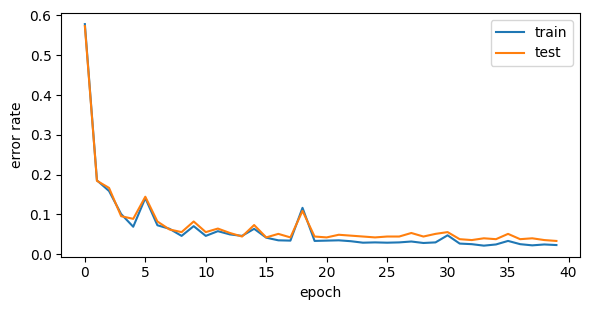

In [7]:
def train(X, y, Xte, yte, lr=0.5, B=64, epochs=40):
    theta = np.zeros((X.shape[1], k))
    hist = []
    for _ in range(epochs):
        order = np.random.permutation(X.shape[0])     # reshuffle each epoch
        for i in range(0, X.shape[0], B):
            idx = order[i:i+B]
            _, g = loss_and_grad(X[idx], y[idx], theta)
            theta -= lr * g
        hist.append((error_loss(X, y, theta), error_loss(Xte, yte, theta)))
    return theta, hist

theta, hist = train(X_train, y_train, X_test, y_test)
tr, te = zip(*hist)
print(f"train error {tr[-1]:.4f}   test error {te[-1]:.4f}   accuracy {1-te[-1]:.4f}")

plt.figure(figsize=(6, 3.2))
plt.plot(tr, label="train"); plt.plot(te, label="test")
plt.xlabel("epoch"); plt.ylabel("error rate"); plt.legend(); plt.tight_layout(); plt.show()

## 6. What the learned parameters look like

$\theta$ has one column per class, and each column has one entry per input pixel. Reshaping a
column back to 8×8 shows which pixels push the score for that digit up or down — the closest
thing a linear model has to a learned feature.

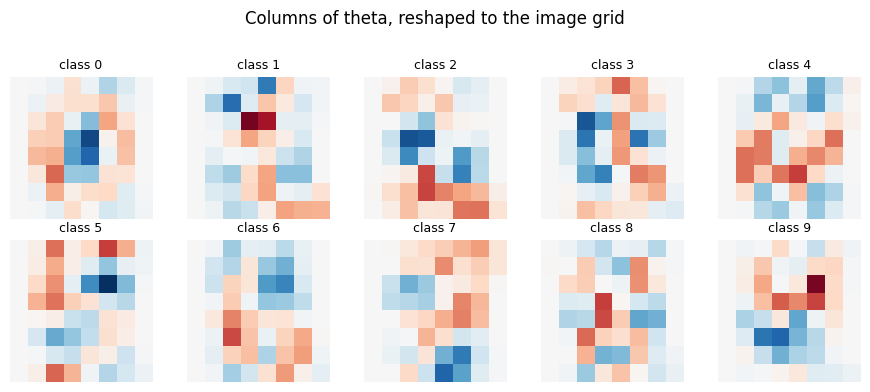

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(9, 3.8))
lim = np.abs(theta).max()
for c, ax in enumerate(axes.ravel()):
    ax.imshow(theta[:, c].reshape(8, 8), cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(f"class {c}", fontsize=9); ax.axis("off")
plt.suptitle("Columns of theta, reshaped to the image grid", y=1.02)
plt.tight_layout(); plt.show()

## Summary

- The hypothesis returns **scores**, not labels, because labels carry no gradient.
- 0/1 error is the right thing to report and the wrong thing to train on — it is flat.
- Keep the softmax **inside** the loss; computing it explicitly invites `log(0)`.
- $\nabla_h \ell = z - e_y$, and shape matching gives $\nabla_\theta \ell = X^{\mathsf{T}}(Z - I_y)$.
- That shape argument is not a proof, so it must be checked numerically — which we did.

Next: a linear hypothesis class can only draw straight boundaries. Lecture 3 asks what to do
about that, and finds that the obvious fix does not work.